[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/su-ntu-ctp/6m-data-3.8-Computer-Vision/blob/main/notebooks/assignment.ipynb)

**Where to run this notebook**

- **Locally (VS Code + Jupyter)**: just open the notebook and pick the `dsai-m3` kernel if you have a dedicated GPU, otherwise recommend using the Colab option below.
- **Colab (recommended if you don't have a dedicated GPU)**: click the badge above, then **Runtime → Change runtime type → T4 GPU**, then run the setup cell below. It clones the repo, installs missing deps, and `cd`s into the right working directory.


In [1]:
# === Colab-compat setup (no-op when running locally) ===
# This cell makes the notebook work in BOTH places: on your own computer, OR on
# Google Colab (a free cloud notebook). It detects where you are and, if you're on
# Colab, downloads the course code and installs the libraries you'll need.
import os, sys

# `sys.modules` lists everything Python has imported. Colab pre-imports "google.colab",
# so its presence is a reliable way to detect "am I running inside Colab?".
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    REPO_URL = "https://github.com/su-ntu-ctp/6m-data-3.8-Computer-Vision.git"
    REPO_DIR = "/content/6m-data-3.8-Computer-Vision"
    LESSON_DIR = "notebooks"

    # Only download the code once — skip if the folder already exists.
    if not os.path.exists(REPO_DIR):
        print(f"Cloning repo into {REPO_DIR} ...")
        os.system(f"git clone -q {REPO_URL} {REPO_DIR}")

    # Move into the lesson folder so file paths in later cells line up.
    os.chdir(f"{REPO_DIR}/{LESSON_DIR}")
    print(f"Working directory: {os.getcwd()}")

    # Colab has torch + torchvision pre-installed. Install the rest.
    os.system("pip install -q sentence-transformers transformers")
    print("Colab setup done.")

# Threading caps — set here for both local and Colab runs (no .env file needed).
# These tell the math libraries to use a single CPU thread, which keeps runtimes
# predictable on shared machines. `setdefault` only sets a value if it isn't
# already set, so this is harmless if your environment already configured them.
# (Loop form prevents Jupyter from auto-displaying the return value.)
for _key, _val in [("OMP_NUM_THREADS", "1"), ("MKL_NUM_THREADS", "1"), ("TOKENIZERS_PARALLELISM", "false")]:
    os.environ.setdefault(_key, _val)


# L08 · Assignment — CIFAR-10 classifier

> *Marcus is happy with the Fashion-MNIST proof of concept. Now he hands you the next dataset: 10 categories of small **colour photos** (32×32) — animals, vehicles, ships. CIFAR-10 is the standard "harder than Fashion-MNIST" benchmark and lives much closer to the ImageNet domain that pretrained models were trained on.*

In this assignment you will:

**Part A.** Build a CNN from scratch on CIFAR-10. The starter architecture should land around 55-65% test accuracy. **Stretch goal: get above 65%** by adding BatchNorm, data augmentation, or more capacity (see Extensions notebook for ideas).

**Part B.** Apply transfer learning with a pretrained ResNet18. **Target: ≥ 75% test accuracy.**

**Part C.** Reflect — why does transfer learning behave so differently on CIFAR-10 than on Fashion-MNIST?

Submit your completed notebook. Total runtime: ~30-40 minutes on CPU.

---

## Setup

In [2]:
# Setup cell: import the libraries we need, lock in randomness for reproducible
# results, then download CIFAR-10 and carve out a smaller training set so the
# notebook finishes in a reasonable time.
import time
import numpy as np                     # numerical arrays
import matplotlib.pyplot as plt        # plotting / showing images
import torch                           # PyTorch — the deep-learning framework
import torch.nn as nn                  # neural-network building blocks (layers, losses)
import torchvision.transforms as T     # image preprocessing pipelines
from torchvision.datasets import CIFAR10
from torchvision.models import resnet18, ResNet18_Weights   # a pretrained model
from torch.utils.data import DataLoader, Subset

torch.set_num_threads(1)   # keep CPU usage to one thread for predictable timing
# Fixing the random "seed" means shuffling, weight init, etc. happen the same way
# every run — so your results are reproducible instead of changing each time.
torch.manual_seed(0)
np.random.seed(0)

# A "transform" is a recipe applied to every image before the model sees it.
# CIFAR-10 is 32×32 colour. Auto-downloads on first use into data/cifar10/.
basic_tf = T.Compose([
    T.ToTensor(),   # convert image to a tensor with pixel values scaled to 0–1
    # Normalize shifts/scales each colour channel so values are centred around 0.
    # These specific numbers are the known mean/std of the CIFAR-10 dataset.
    T.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616]),  # CIFAR stats
])

# train=True gives the 50k training images; train=False gives the 10k test images.
train_full = CIFAR10(root='data/cifar10', train=True, download=True, transform=basic_tf)
test_full  = CIFAR10(root='data/cifar10', train=False, download=True, transform=basic_tf)
CLASSES = train_full.classes   # the 10 category names (airplane, cat, ...)

# For runtime budget: subsample training set to 1000/class = 10K. Test stays at 10K for stable eval.
# This helper walks through the dataset and keeps only the first `n` images of
# each class, then stops early once every class has enough — a fast way to shrink data.
def first_n_per_class(dataset, n, n_classes=10):
    counts = {c: 0 for c in range(n_classes)}   # how many we've kept per class
    indices = []
    for i, (_, y) in enumerate(dataset):        # y is the class label of image i
        if counts[y] < n:
            indices.append(i); counts[y] += 1
        if all(v >= n for v in counts.values()): break   # stop once all classes are full
    return Subset(dataset, indices)             # a view onto just those images

train_ds = first_n_per_class(train_full, n=1000)  # 10,000 images
test_ds  = test_full                              # 10,000 images
print(f"Train: {len(train_ds):,}  |  Test: {len(test_ds):,}")
print(f"Classes: {CLASSES}")

Train: 10,000  |  Test: 10,000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## Visualise the data

CIFAR-10 images are tiny — 32×32 pixels. Even humans struggle on some of them.

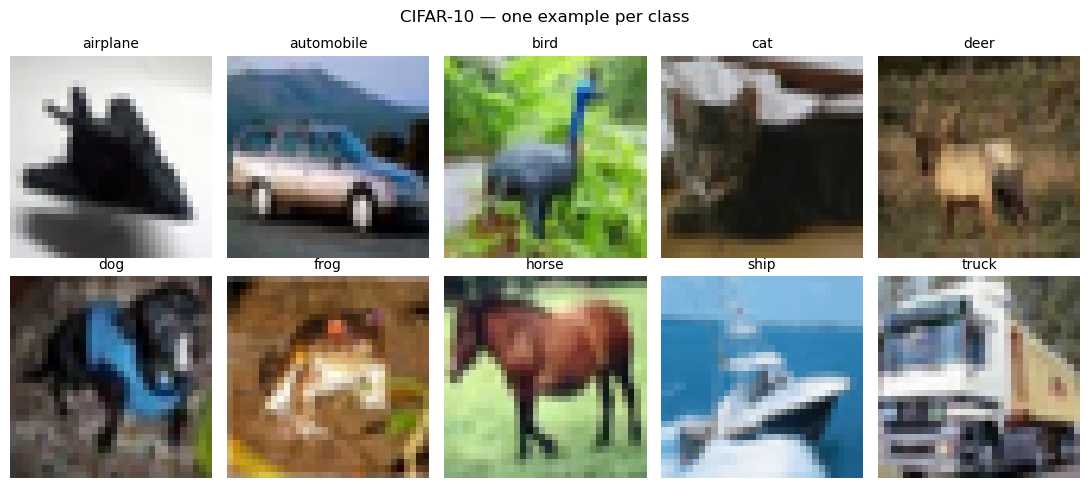

In [3]:
# Sanity-check the data by displaying one example image from each of the 10 classes.
# Seeing the actual pictures helps you appreciate how tiny and blurry 32×32 images are.
fig, axes = plt.subplots(2, 5, figsize=(11, 5))   # a 2-row × 5-column grid = 10 slots
for cls_idx, ax in enumerate(axes.flat):          # loop over each grid slot / class
    # Find the first image in the training set whose label matches this class.
    idx = next(i for i, (_, y) in enumerate(train_ds) if y == cls_idx)
    img, _ = train_ds[idx]
    # Tensors store images as (channels, height, width); imshow wants (H, W, channels),
    # so permute reorders the axes before converting to a NumPy array.
    img_disp = img.permute(1, 2, 0).numpy()
    # Earlier we normalised the pixels; here we reverse it (multiply by std, add mean)
    # so the colours look natural again.
    img_disp = img_disp * np.array([0.2470, 0.2435, 0.2616]) + np.array([0.4914, 0.4822, 0.4465])
    img_disp = np.clip(img_disp, 0, 1)   # keep values in the valid 0–1 range for display
    ax.imshow(img_disp)
    ax.set_title(CLASSES[cls_idx], fontsize=10)
    ax.axis('off')                       # hide the x/y pixel axes
plt.suptitle('CIFAR-10 — one example per class')
plt.tight_layout()                       # stop titles/plots from overlapping
plt.show()

---

## 📚 Choose your track

This assignment has **two tracks**. Pick **one** based on your background — you don't need to do both.

| Track | Who it's for | What you'll do |
|---|---|---|
| **🟢 Foundational Track** | Learners new to ML / programming | Part A — CNN from scratch on CIFAR-10 (target ≥ 55%) |
| **🔵 Advanced Track** | Learners with prior ML background | Part B — transfer learning with ResNet18 + fine-tuning (target ≥ 75%) + Part C compare |

If you're unsure, start with the **Foundational Track**. If it feels easy, skip ahead to the **Advanced Track** — both tracks cover the same lesson outcomes; only the scaffolding differs.

---


---

# 🟢 Foundational Track

> *No prior ML background needed. The cells below are scaffolded — read the worked example, then fill in the blanks. Hints are included.*

---


### 🧩 How the fill-in-the-blank cells work

The code cells in this track have **blanks** marked with `____` (four underscores) and a `# TODO` comment that tells you what goes there. Your job is to replace each `____` with the right value.

- **Read the comment above each blank first** — it usually contains the hint (sometimes the exact answer).
- A cell with a `____` left in it **will not run** — Python raises a `SyntaxError`. That's expected; fill every blank, then run the cell.
- The first block of each exercise is done for you as a **worked example** — copy its pattern for the blanks below it.
- Stuck? The Advanced Track further down has the same logic written out in full — but try the hints first.

> 💡 Tip: run a cell *after each edit* so you catch mistakes early instead of all at once.


---

## Part A — CNN from scratch

**Baseline target: ≥ 55% test accuracy** (the starter architecture below should clear this in 8 epochs).
**Stretch goal: ≥ 65%** — add BatchNorm after each conv, train more epochs, or apply data augmentation.

Suggested starting architecture (modify freely):

- Conv(3 → 32, k=3, padding=1) + ReLU + MaxPool(2)  → 16×16
- Conv(32 → 64, k=3, padding=1) + ReLU + MaxPool(2) → 8×8
- Conv(64 → 128, k=3, padding=1) + ReLU + MaxPool(2) → 4×4
- Flatten + Linear(128·4·4 → 128) + ReLU + Linear(128 → 10)

### A.1 · Define your model

In [4]:
# Part A: define a Convolutional Neural Network (CNN) from scratch.
# A CNN works in two stages: `features` uses convolution layers to detect visual
# patterns (edges, textures, shapes), then `classifier` turns those patterns into
# a score for each of the 10 classes.
#
# ┌─ YOUR TASK ─────────────────────────────────────────────────────────────────┐
# │ Replace every  ____  below. Block 1 is a WORKED EXAMPLE — copy its pattern.  │
# │ Each Conv2d takes (channels_in, channels_out, kernel_size, padding).         │
# └──────────────────────────────────────────────────────────────────────────────┘
class CifarCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Sequential = run these layers one after another, in order.
        self.features = nn.Sequential(
            # WORKED EXAMPLE — block 1: 3 colour channels in -> 32 feature maps out.
            # ReLU adds non-linearity; MaxPool2d(2) halves height & width (32x32 -> 16x16).
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),         # -> 16x16

            # TODO block 2: feed the 32 maps from block 1 in, produce 64 maps out.
            # Hint: channels_in must match the previous block's channels_out (32).
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),    # -> 8x8

            # TODO block 3: feed 64 maps in, produce 128 maps out (same k=3, padding=1).
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),    # -> 4x4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),   # flatten the feature grid into one long vector
            # TODO: after 3 poolings the grid is 128 channels x 4 x 4.
            # Hint: the flattened input size is 128 * 4 * 4. Output a hidden layer of 128.
            nn.Linear(128 * 4 * 4, 128), nn.ReLU(),
            # TODO: final layer outputs one raw score (logit) per class.
            # Hint: how many classes does CIFAR-10 have?
            nn.Linear(128, 10),
        )
    # forward defines how data flows: extract features, then classify.
    def forward(self, x):
        # TODO: pass x through the feature extractor, then the classifier.
        # Hint: self.classifier(self.features(x))
        return self.classifier(self.features(x))

cnn = CifarCNN()
# Count the learnable numbers (weights) in the model — a rough size measure.
print(f"CifarCNN parameter count: {sum(p.numel() for p in cnn.parameters()):,}")

# Quick shape check: feed in 2 fake images and confirm we get 2 rows of 10 scores.
# If your blanks are correct, this prints  torch.Size([2, 10]).
with torch.no_grad():
    out = cnn(torch.randn(2, 3, 32, 32))   # 2 images, 3 channels, 32x32 pixels
print(f"Output logits shape: {out.shape}")

CifarCNN parameter count: 356,810
Output logits shape: torch.Size([2, 10])


### A.2 · Train

In [5]:
# Train the from-scratch CNN. We loop over the data several times ("epochs"),
# each time letting the model make predictions, measure its error, and nudge its
# weights to do better. Then we check accuracy on the held-out test set.
BATCH = 128       # how many images the model processes at once
EPOCHS_A = 8      # how many full passes over the training data
LR = 1e-3         # learning rate: how big a step to take when updating weights

# DataLoaders feed images to the model in batches. shuffle=True on training data
# mixes the order each epoch so the model doesn't memorise the sequence.
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False)

# Adam is a popular optimiser — it's the algorithm that adjusts the weights.
opt = torch.optim.Adam(cnn.parameters(), lr=LR)
# CrossEntropyLoss measures how wrong the predictions are for a classification task.
crit = nn.CrossEntropyLoss()

# Helper to measure accuracy: fraction of test images the model labels correctly.
def evaluate(model, loader):
    model.eval()                    # switch to evaluation mode (no training behaviour)
    correct, total = 0, 0
    with torch.no_grad():           # don't track gradients — we're only measuring
        for xb, yb in loader:
            preds = model(xb).argmax(dim=1)   # pick the class with the highest score
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    return correct / total

print('Training CifarCNN from scratch...')
t0 = time.time()
for epoch in range(1, EPOCHS_A + 1):
    cnn.train()                     # switch to training mode
    running = 0.0                   # accumulate loss to report an average
    for xb, yb in train_loader:     # xb = batch of images, yb = their true labels
        # ┌─ YOUR TASK: the 4 steps of one training update ──────────────────────┐
        # │ This loop is the heart of deep learning. Fill in the 4 blanks in order.│
        # └────────────────────────────────────────────────────────────────────────┘
        opt.zero_grad()             # TODO 1: clear gradients from the last step.   Hint: opt.zero_grad()
        loss = crit(cnn(xb), yb)    # TODO 2: predict on xb, then compare to labels. Hint: feed cnn(xb)
        loss.backward()             # TODO 3: backpropagate to compute gradients.    Hint: loss.backward()
        opt.step()                  # TODO 4: apply the weight update.               Hint: opt.step()
        running += loss.item() * xb.size(0)
    acc = evaluate(cnn, test_loader)   # check test accuracy after each epoch
    print(f"  epoch {epoch} | loss {running/len(train_ds):.4f} | test acc {acc:.4f}")
scratch_acc = evaluate(cnn, test_loader)   # final accuracy, saved for the Part C comparison
print(f"\n[Part A] CNN from scratch final test accuracy: {scratch_acc:.4f}")
print(f"Training time: {time.time()-t0:.1f}s")
# Quick pass/fail readouts against the assignment targets.
print(f"\nBaseline (≥0.55): {'PASS' if scratch_acc >= 0.55 else 'BELOW — try more epochs'}")
print(f"Stretch  (≥0.65): {'PASS' if scratch_acc >= 0.65 else 'try adding BatchNorm or augmentation'}")

Training CifarCNN from scratch...
  epoch 1 | loss 1.9096 | test acc 0.4253
  epoch 2 | loss 1.4916 | test acc 0.4733
  epoch 3 | loss 1.3133 | test acc 0.5003
  epoch 4 | loss 1.2131 | test acc 0.5521
  epoch 5 | loss 1.0832 | test acc 0.5755
  epoch 6 | loss 0.9980 | test acc 0.5961
  epoch 7 | loss 0.9215 | test acc 0.6251
  epoch 8 | loss 0.8119 | test acc 0.5941

[Part A] CNN from scratch final test accuracy: 0.5941
Training time: 120.9s

Baseline (≥0.55): PASS
Stretch  (≥0.65): try adding BatchNorm or augmentation


### 💾 Save Model A for deployment

You'll deploy your models to Hugging Face later. Save this from-scratch CNN now.
We save the **`state_dict`** (the learned weights) — the standard, portable format.


In [7]:
# Save Model A (the from-scratch CNN) so you can deploy it on Hugging Face later.
torch.save(cnn.state_dict(), 'cifar_cnn.pt')
print('Saved cifar_cnn.pt')


Saved cifar_cnn.pt


---

# 🔵 Advanced Track

> *For learners with prior ML background. Minimal scaffolding — you decide the approach. You're welcome to peek at the Foundational Track above for reference.*

---


---

## Part B — Transfer learning

**Target: ≥ 75% test accuracy.**

CIFAR-10 is colour natural-photo data, much closer to ImageNet than Fashion-MNIST was. You should see transfer learning help significantly here.

Plan:
1. Resize 32×32 → 96×96 (ResNet18's bigger receptive field works better on more pixels)
2. Apply ImageNet normalisation
3. Load pretrained ResNet18, replace `fc`
4. Train head only for a few epochs
5. (Optional but recommended) unfreeze `layer4` and fine-tune

### B.1 · Build the transfer pipeline

In [6]:
# Part B: set up transfer learning. Instead of training from scratch, we reuse a
# ResNet18 that was already trained on millions of ImageNet photos, and adapt it.
# First we rebuild the data pipeline to match what that pretrained model expects.
imagenet_tf = T.Compose([
    T.Resize(96),     # ResNet was trained on bigger images; upscale 32×32 -> 96×96
    T.ToTensor(),
    # Use ImageNet's mean/std (not CIFAR's) because the pretrained model was
    # normalised with these numbers during its original training.
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Reload CIFAR-10 with the new transform, then take the same 1000-per-class subset.
train_full_rgb = CIFAR10(root='data/cifar10', train=True,  download=True, transform=imagenet_tf)
test_rgb       = CIFAR10(root='data/cifar10', train=False, download=True, transform=imagenet_tf)
train_rgb = first_n_per_class(train_full_rgb, n=1000)

# Build a ResNet18 with pretrained weights, freeze it, and swap in a fresh output layer.
def build_resnet_head(n_classes=10):
    m = resnet18(weights=ResNet18_Weights.DEFAULT)   # load the pretrained network
    for p in m.parameters(): p.requires_grad = False  # freeze: keep all learned weights fixed
    in_f = m.fc.in_features                           # size feeding into the final layer
    # Replace the original 1000-class ImageNet head with a new 10-class one.
    # Only this new layer is trainable (the rest stays frozen).
    m.fc = nn.Linear(in_f, n_classes)
    return m

xfer = build_resnet_head()
print(f"Total params    : {sum(p.numel() for p in xfer.parameters()):,}")
# Notice how few params are trainable — only the new head — which makes training fast.
print(f"Trainable params: {sum(p.numel() for p in xfer.parameters() if p.requires_grad):,}")

Total params    : 11,181,642
Trainable params: 5,130


### B.2 · Train the head

In [7]:
# Train ONLY the new output layer (the "head") while the pretrained body stays frozen.
# Because the frozen layers already know how to "see" general image features, the
# head just learns to map those features to CIFAR's 10 classes — and learns fast.
train_rgb_loader = DataLoader(train_rgb, batch_size=BATCH, shuffle=True)
test_rgb_loader  = DataLoader(test_rgb,  batch_size=256, shuffle=False)

# Pass only the head's parameters to the optimiser, so only they get updated.
opt_xfer = torch.optim.Adam(xfer.fc.parameters(), lr=1e-3)

EPOCHS_B = 3
print('Training ResNet18 head on CIFAR-10...')
t0 = time.time()
for epoch in range(1, EPOCHS_B + 1):
    xfer.train()
    for xb, yb in train_rgb_loader:
        opt_xfer.zero_grad()        # reset gradients
        loss = crit(xfer(xb), yb)   # predict and measure error
        loss.backward()             # compute gradients
        opt_xfer.step()             # update the head's weights
    acc = evaluate(xfer, test_rgb_loader)
    print(f"  epoch {epoch} | test acc {acc:.4f}")
# Save this "head-only" accuracy so we can compare it later in Part C.
head_only_acc = evaluate(xfer, test_rgb_loader)
print(f"\nHead-only transfer accuracy: {head_only_acc:.4f}  (training time {time.time()-t0:.1f}s)")

Training ResNet18 head on CIFAR-10...
  epoch 1 | test acc 0.6831
  epoch 2 | test acc 0.7109
  epoch 3 | test acc 0.7251

Head-only transfer accuracy: 0.7251  (training time 590.8s)


### B.3 · Fine-tune `layer4` (recommended for the 75% target)

In [8]:
# Fine-tuning: now we also unfreeze the LAST convolution block (layer4) and train it
# alongside the head. This lets the model adjust its higher-level feature detectors
# to CIFAR specifically, usually pushing accuracy past the 75% target.
# Unfreeze the last conv block
for p in xfer.layer4.parameters():
    p.requires_grad = True          # allow these weights to update again

# The optimiser now updates BOTH the head and layer4.
finetune_params = list(xfer.fc.parameters()) + list(xfer.layer4.parameters())
# Use a SMALL learning rate (1e-4) so we gently nudge the already-good pretrained
# weights rather than overwriting what they learned.
opt_ft = torch.optim.Adam(finetune_params, lr=1e-4)

print('Fine-tuning last conv block (layer4)...')
t0 = time.time()
for epoch in range(1, 3):           # range(1, 3) runs 2 epochs (1 and 2)
    xfer.train()
    for xb, yb in train_rgb_loader:
        opt_ft.zero_grad()
        loss = crit(xfer(xb), yb)
        loss.backward()
        opt_ft.step()
    acc = evaluate(xfer, test_rgb_loader)
    print(f"  fine-tune epoch {epoch} | test acc {acc:.4f}")
transfer_acc = evaluate(xfer, test_rgb_loader)   # final transfer-learning accuracy
print(f"\n[Part B] Transfer learning final accuracy: {transfer_acc:.4f}")
print(f"Total time (head + fine-tune): {time.time()-t0:.1f}s")
print(f"\nTarget ≥ 0.75? {'✅ PASS' if transfer_acc >= 0.75 else '❌ Below target — try more epochs or unfreezing more layers'}")

Fine-tuning last conv block (layer4)...
  fine-tune epoch 1 | test acc 0.8233
  fine-tune epoch 2 | test acc 0.8370

[Part B] Transfer learning final accuracy: 0.8370
Total time (head + fine-tune): 491.4s

Target ≥ 0.75? ✅ PASS


### 💾 Save Model B for deployment

Save your fine-tuned transfer-learning model too. In the deployment app you'll be
able to switch between Model A and Model B and compare them on the same photo.


In [9]:
# Save Model B (the fine-tuned ResNet18) for Hugging Face deployment.
torch.save(xfer.state_dict(), 'cifar_resnet.pt')
print('Saved cifar_resnet.pt')
print('Both models saved. Use them in the Hugging Face deployment exercise '
      '(see huggingface_deploy_cifar/DEPLOY_CIFAR_GUIDE.md).')


Saved cifar_resnet.pt
Both models saved. Use them in the Hugging Face deployment exercise (see huggingface_deploy_cifar/DEPLOY_CIFAR_GUIDE.md).


---

## Part C — Compare and reflect

### C.1 · Head-to-head table

In [10]:
# Part C: print a tidy comparison table of the three approaches we tried, using the
# accuracy numbers we saved earlier. This makes the benefit of transfer learning obvious.
# The :35 and :>10 inside the f-strings control column width and alignment for neat output.
print(f"{'Approach':35} {'Test acc':>10}")
print('-' * 47)
print(f"{'CifarCNN from scratch':35} {scratch_acc:>10.4f}")
print(f"{'ResNet18 head-only transfer':35} {head_only_acc:>10.4f}")
print(f"{'ResNet18 fine-tuned (layer4)':35} {transfer_acc:>10.4f}")
# Report the improvement of fine-tuned transfer over the from-scratch CNN,
# expressed in percentage points (the *100 converts the 0–1 fraction to %).
print(f"\nTransfer gain over from-scratch: {(transfer_acc - scratch_acc)*100:+.2f} percentage points")

Approach                              Test acc
-----------------------------------------------
CifarCNN from scratch                   0.5941
ResNet18 head-only transfer             0.7251
ResNet18 fine-tuned (layer4)            0.8370

Transfer gain over from-scratch: +24.29 percentage points


### C.2 · Reflection questions

Answer in markdown below (one or two sentences each):

**Q1.** On Fashion-MNIST (NB 04) head-only transfer learning **lost** to a from-scratch CNN. On CIFAR-10 here, head-only transfer typically **wins** even before fine-tuning. What's the structural difference?

**Q2.** Look at your fine-tuning step. Why use learning rate 1e-4 instead of the 1e-3 you used for head-only training?

**Q3.** If Marcus's actual product photos are 600×600 colour, would you train a CNN from scratch or fine-tune a pretrained model? Justify in one sentence.

*Your answers here:*

**A1.** 
Fashion-MNIST is grayscale, low-texture, line-art-like clothing silhouettes — very different from the natural-photo, RGB, texture-rich statistics ImageNet was pretrained on, so the frozen ImageNet features transfer poorly there. CIFAR-10 is itself made of natural RGB photos (animals, vehicles), so the low- and mid-level features ResNet18 learned from ImageNet (edges, textures, color gradients, object parts) are already well-suited to it, letting a frozen backbone with just a new head perform well immediately.

**A2.** 
Head-only training only updates a freshly-initialized linear layer, so a larger LR (1e-3) is fine since those weights start from scratch and need big updates to learn quickly. Fine-tuning layer4 updates pretrained weights that already encode useful, well-tuned features; a small LR (1e-4) makes small, gentle adjustments so training doesn't overwrite or destroy that prior knowledge ("catastrophic forgetting") while still letting the features specialize toward CIFAR-10.

**A3.** *Fine-tune a pretrained model — 600×600 color product photos are natural images much closer to ImageNet's domain (and far more complex/detailed than CIFAR's 32×32 thumbnails), so transfer learning would converge faster and reach higher accuracy with far less labeled data than training a CNN from scratch.

---

## Submission checklist

- [ ] Part A — CifarCNN trained, baseline ≥ 55% test accuracy (stretch: ≥ 65%)
- [ ] Part B — Transfer model trained, ≥ 75% test accuracy
- [ ] Part C — Comparison table printed
- [ ] Part C — Reflection answers filled in

Save the notebook with outputs and submit.